# 1. Introduction
This project explores the evolution of AES encryption modes. By building these iteratively, I was able to observe how different modes handle padding, initialization vectors (IVs), and data integrity. It provides a Python-based utility to encrypt and decrypt images using the AES block cipher. It supports four modes of operation: ECB, CBC, CFB, and CTR.
#
### How to use:
- To Encrypt: *python aes_enc_dec.py enc <filename.jpg>*

- To Decrypt: *python aes_enc_dec.py dec <filename_encrypted.bin>*

Note: You must provide the exact Hex key and IV (if applicable) used during encryption to successfully recover the file.

# 2. Building Separate Scripts
This section documents the iterative development of my AES tool. Each block represents a learning milestone where I addressed specific cryptographic constraints. I start off by importing the required libraries for my crypto journey, most notably, pycryptodome.

In [ ]:
import sys, os
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad

## a. Electronic Codebook
I started with Electronic Codebook (ECB) mode to establish a baseline. I learned that ECB requires manual padding because it processes fixed 16-byte blocks. ECB is the simplest mode. However, it is fundamentally insecure because it encrypts identical blocks of data into identical ciphertexts. It doesn't use an IV, so patterns from the original file (like the shapes in an image) can still be seen in the encrypted output.

In [ ]:
def encrypt_ecb(data, key):
    padded_data = pad(data, 16)
    cipher = AES.new(key, AES.MODE_ECB)
    return cipher.encrypt(padded_data)

def decrypt_ecb(ciphertext, key):
    cipher = AES.new(key, AES.MODE_ECB)
    decrypted_data = cipher.decrypt(ciphertext)
    return unpad(decrypted_data, 16)

## b. Cipher Block Chaining (Adds Randomness)
Next, I implemented CBC mode which fixes the pattern leakage of ECB. This mode uses an Initialization Vector (IV). By adding randomness, the same file encrypted twice will result in two completely different ciphertext files.

In [ ]:
def encrypt_cbc(data, key, iv):
    padded_data = pad(data, 16)
    cipher = AES.new(key, AES.MODE_CBC, iv)
    return cipher.encrypt(padded_data)

def decrypt_cbc(ciphertext, key, iv):
    cipher = AES.new(key, AES.MODE_CBC, iv)
    decrypted_data = cipher.decrypt(ciphertext)
    return unpad(decrypted_data, 16)

## c. Cipher Feedback (Stream-based Encryption)
CFB converts the block cipher into a self-synchronizing stream cipher. It encrypts the previous ciphertext block to produce a keystream, which is then XORed with the plaintext. This eliminates the need for manual block padding.

In [ ]:
def encrypt_cfb(data, key, iv):
    cipher = AES.new(key, AES.MODE_CFB, iv)
    return cipher.encrypt(data)

def decrypt_cfb(ciphertext, key, iv):
    cipher = AES.new(key, AES.MODE_CFB, iv)
    return cipher.decrypt(ciphertext)

## d. Counter Mode
CTR mode treats the cipher as a stream by encrypting an incrementing counter value combined with a nonce. It is highly efficient for modern hardware because it allows for parallel processing; multiple blocks can be encrypted or decrypted simultaneously.

In [ ]:
def encrypt_ctr(data, key, nonce):
    cipher = AES.new(key, AES.MODE_CTR, nonce=nonce)
    return cipher.encrypt(data)

def decrypt_ctr(ciphertext, key, nonce):
    cipher = AES.new(key, AES.MODE_CTR, nonce=nonce)
    return cipher.decrypt(ciphertext)

# 3. Modular to Unified System
Instead of maintaining separate scripts for each mode, I combined them into a unified interface. By abstracting the mode_choice logic, the encrypt and decrypt functions act as controllers. They handle the common administrative tasks such as padding, IV generation, and file I/O while delegating the cryptographic transformation to the specific AES.MODE_ requested by the user.
- The Initialization Vector (IV): I figured that the general standard is to embed the IV as the first 16 bytes of the cyphertext. Regardless of the mode (CBC, CFB, or CTR), the first 16 bytes of the output file are reserved for the IV/Nonce.
- The Routing Logic: The decrypt_file function reads these 16 bytes first, effectively unpacking the metadata, and then routes the remainder of the file (the actual ciphertext) to the correct mode-specific AES algorithm.
#
The way the function is called, together with the arguments provided, determines whether the operation being performed is encryption or decryption.
#
In both functions, I prompt the user for the required mode and, use the cipher variable to determine the mode, depending on what the user would have selected.

In [1]:
%%writefile aes_enc_dec.py
import sys, os
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad

def encrypt_file(filename):
    print("Select the mode of operation:")
    print("0 - ECB")
    print("1 - CBC")
    print("2 - CFB")
    print("3 - CTR")
    mode_choice = input("Enter the number corresponding to your choice:")
    enc_key = os.urandom(16)
    print(f"Encryption key: {enc_key.hex()}")

    with open(filename, 'rb') as f:
        data = f.read()

    if mode_choice in ['0', '1']:
        data = pad(data, 16)

    if mode_choice == '0':
        cipher = AES.new(enc_key, AES.MODE_ECB)
        iv = b""
    else:
        iv = os.urandom(16)
        print(f"IV/Nonce: {iv.hex()}")
        if mode_choice == '1':
            cipher = AES.new(enc_key, AES.MODE_CBC, iv)
        elif mode_choice == '2':
            cipher = AES.new(enc_key, AES.MODE_CFB, iv)
        elif mode_choice == '3':
            cipher = AES.new(enc_key, AES.MODE_CTR, nonce=iv)

    ciphertext = cipher.encrypt(data)

    with open(filename.replace('_','.').split('.')[0] + "_encrypted.bin", 'wb') as f:
        f.write(iv + ciphertext)
    print("Encryption completed. File saved as: " + filename.replace('_','.').split('.')[0] + "_encrypted.bin")
    

def decrypt_file(filename):
    print("Select the mode of operation:")
    print("0 - ECB")
    print("1 - CBC")
    print("2 - CFB")
    print("3 - CTR")
    mode_choice = input("Enter the number corresponding to your choice:")
    dec_key = bytes.fromhex(input("Enter the decryption key:"))

    with open(filename, 'rb') as f:
        file_data = f.read()
        
    if mode_choice == '0':
        ciphertext = file_data
        cipher = AES.new(key, AES.MODE_ECB)
    else:
        iv = file_data[:16]
        ciphertext = file_data[16:]
        
        if mode_choice == '1': 
            cipher = AES.new(dec_key, AES.MODE_CBC, iv)
        elif mode_choice == '2': 
            cipher = AES.new(dec_key, AES.MODE_CFB, iv)
        elif mode_choice == '3': 
            user_nonce = input("Enter the nonce (IV) in hex: ")
            user_nonce = bytes.fromhex(user_nonce)
            cipher = AES.new(dec_key, AES.MODE_CTR, nonce=user_nonce)

    decrypted_data = cipher.decrypt(ciphertext)

    if mode_choice in ['0', '1']:
        decrypted_data = unpad(decrypted_data, 16)

    with open("recovered_" + filename.replace('_','.').split('.')[0] + ".jpg", 'wb') as f:
        f.write(decrypted_data)
    print("Decryption completed. File saved as: " + "recovered_" + filename.replace('_','.').split('.')[0] + ".jpg")

if __name__ == "__main__":
    if len(sys.argv) != 3:
        print("Usage: python aes_enc_dec.py [enc|dec] <filename>")
    elif sys.argv[1] == "enc": 
        encrypt_file(sys.argv[2])
    elif sys.argv[1] == "dec": 
        decrypt_file(sys.argv[2])

Overwriting aes_enc_dec.py


## Example Operation in CFB Mode


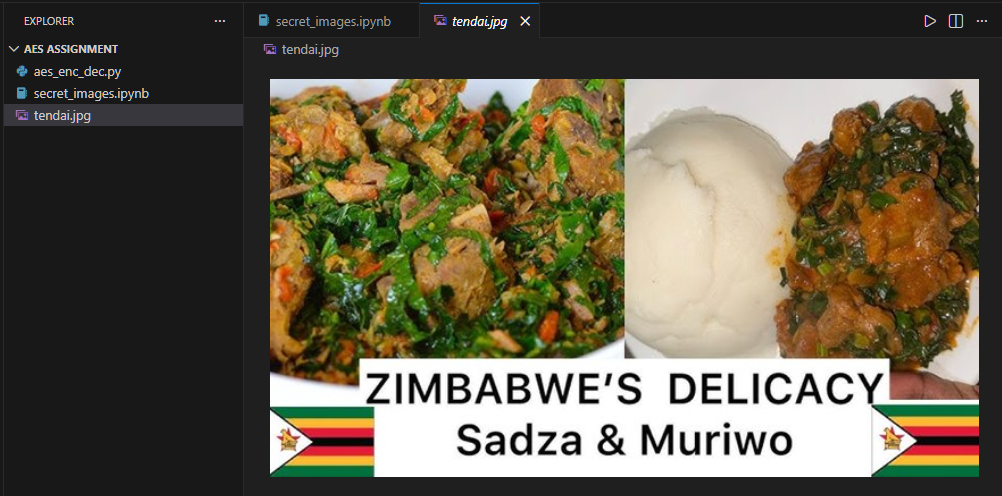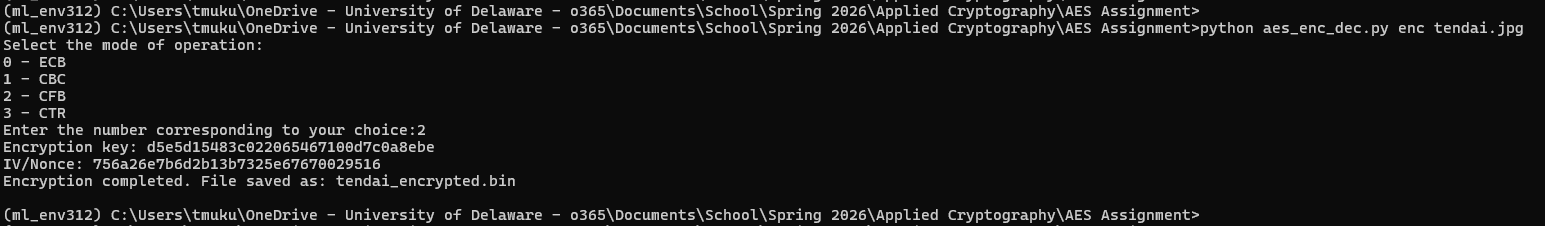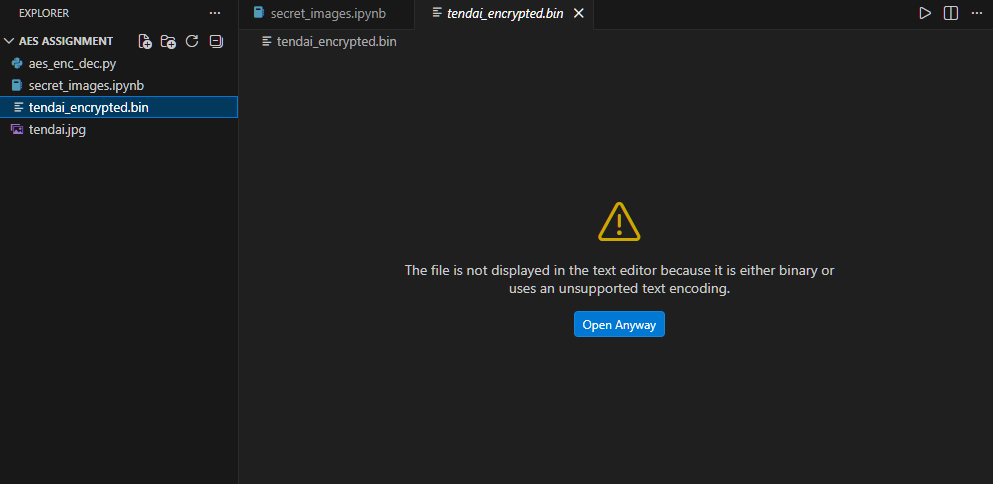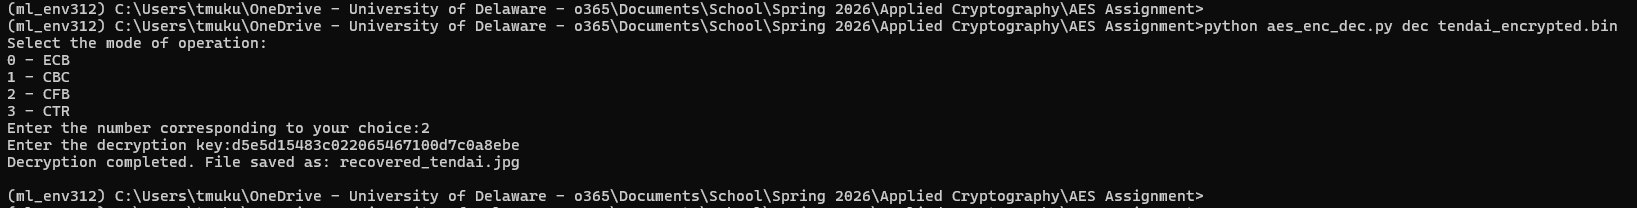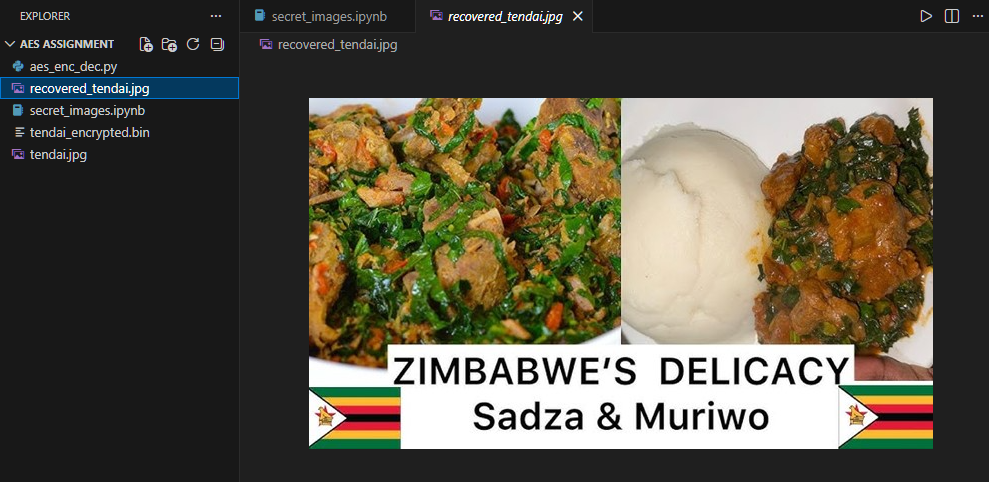

# Attempting Peer File Decryption
To verify my functions are working correctly, I downloaded files encrypted by classmates from the Dicord channel. I was able to decrypt most of them. I show the process for one below, obtained from user LoudPXCX.


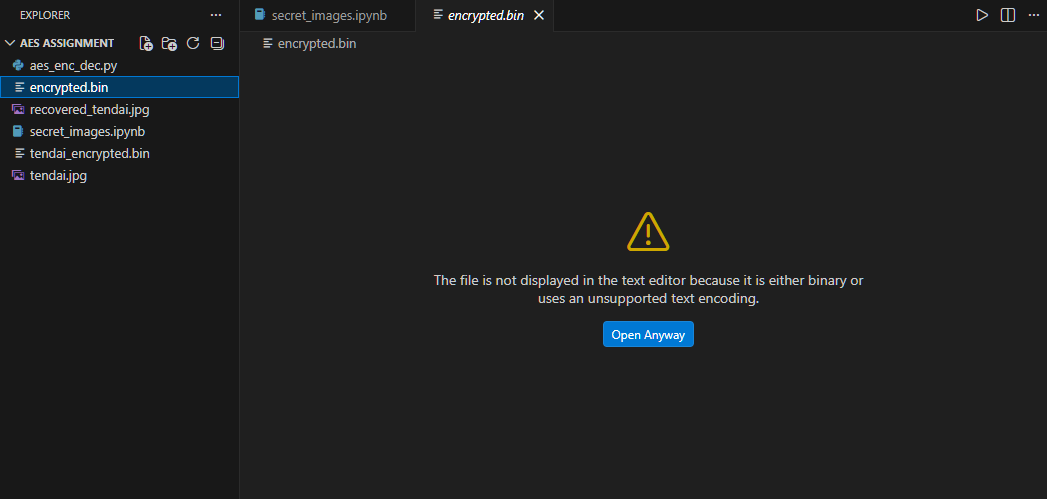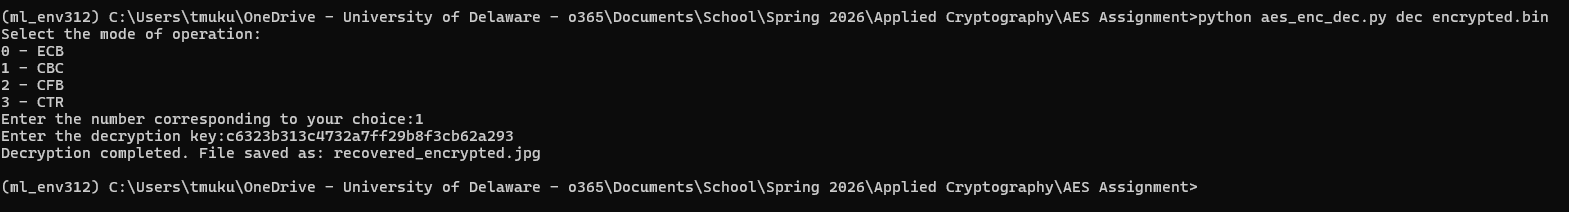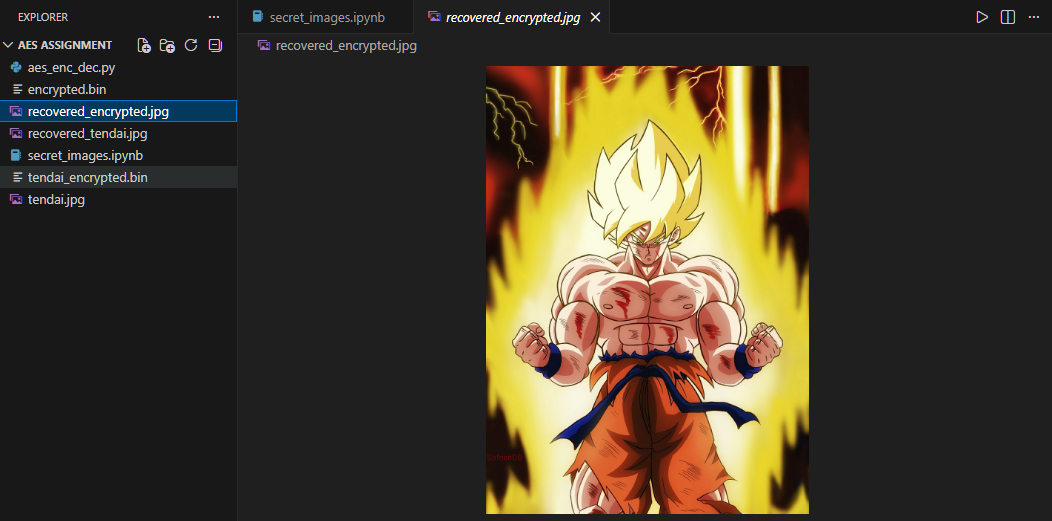